# 02 - Feature Engineering

## Notebook Objectives

- Convert pure daily trip counts into a feature-rich dataset for modeling.
- Engineer trend and seasonality features using STL decomposition.
- Add lag, rolling, and calendar features to capture short-term dynamics and recurring patterns.
- Keep feature engineering consistent with project modules so notebooks and scripts share the same logic.
- Prepare clean model-ready data for training and downstream anomaly detection workflows.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))

from config import AGGREGATED_DATA_MODEL_SOURCE
from src.data.data_loader import load_processed_data
from src.features.feature_builder import build_time_series_features
from src.features.stl_decomposer import build_stl_features

plt.rcParams["figure.figsize"] = (14, 6)

## Trend and seasonality

STL decomposition splits the series into trend, seasonal, and residual components. We keep trend and seasonal as features so the model learns the underlying rhythm of demand, not just noisy day-to-day counts.

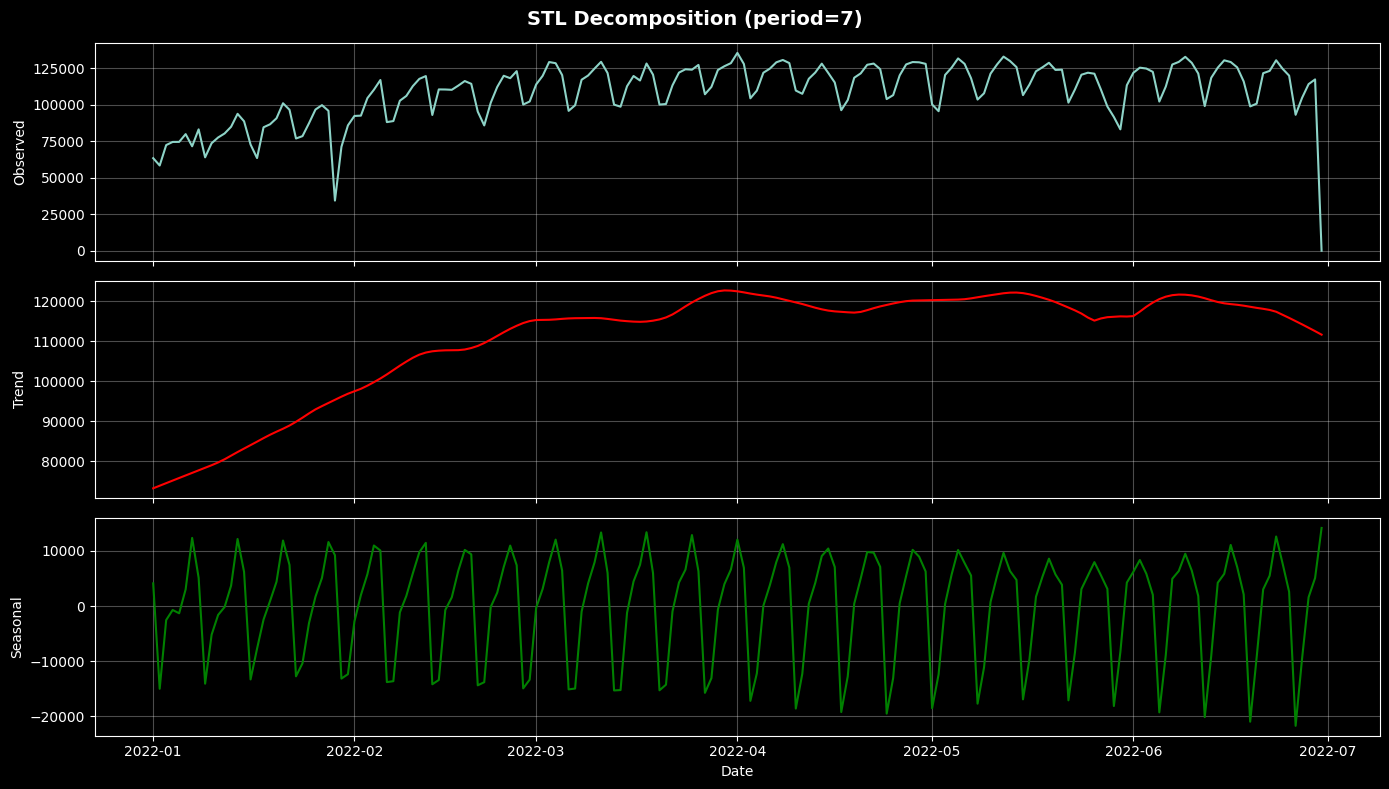

In [2]:
df = load_processed_data(AGGREGATED_DATA_MODEL_SOURCE)
rows_raw = len(df)

df = build_stl_features(df)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df["date"], df["daily_trip_count"])
axes[0].set_ylabel("Observed")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["date"], df["trend"], color="red")
axes[1].set_ylabel("Trend")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["date"], df["seasonal"], color="green")
axes[2].set_ylabel("Seasonal")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

plt.suptitle("STL Decomposition (period=7)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Recent history and calendar signals

Lag and rolling-window features capture short-term momentum and volatility (yesterday, the same day last week, the last 7 days). Calendar features capture recurring day-of-week and monthly effects. Together with trend/seasonal, these give the model everything it needs to recognize "normal".

In [3]:
rows_before_features = len(df)
df = build_time_series_features(df)
rows_after_features = len(df)

feature_cols = [c for c in df.columns if c not in ("date", "daily_trip_count", "trend", "seasonal")]

print(f"Added feature columns: {feature_cols}")
print(f"Rows before: {rows_before_features}, after (lag/rolling introduce NaNs at the start): {rows_after_features}")
print(df[["date", "daily_trip_count", *feature_cols]].head(10))

Added feature columns: ['lag_1', 'lag_7', 'rolling_median_7', 'rolling_std_7', 'day_of_week', 'day_of_month', 'month']
Rows before: 181, after (lag/rolling introduce NaNs at the start): 174
        date  daily_trip_count    lag_1    lag_7  rolling_median_7  \
0 2022-01-08             83177  71590.0  63441.0           72405.0   
1 2022-01-09             64014  83177.0  58421.0           74562.0   
2 2022-01-10             73692  64014.0  72405.0           74562.0   
3 2022-01-11             77603  73692.0  74562.0           74562.0   
4 2022-01-12             80352  77603.0  74592.0           74592.0   
5 2022-01-13             84952  80352.0  79909.0           77603.0   
6 2022-01-14             93817  84952.0  71590.0           77603.0   
7 2022-01-15             88704  93817.0  83177.0           80352.0   
8 2022-01-16             72783  88704.0  64014.0           80352.0   
9 2022-01-17             63518  72783.0  73692.0           80352.0   

   rolling_std_7  day_of_week  day_of_m